In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [4]:
# Configuración visual para los gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print ("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [5]:
#  Conexión a SQL Server

SERVER   = 'GOLDOPC\SQLSERVER2'        # o el nombre de tu instancia, ej: DESKTOP-XXX\SQLEXPRESS
DATABASE = 'SuperstoreDB'

In [6]:
engine = create_engine(
    f'mssql+pyodbc://{SERVER}/{DATABASE}'
    f'?driver=ODBC+Driver+17+for+SQL+Server'
    f'&trusted_connection=yes'    # usa tus credenciales de Windows
)

In [7]:
try:
    with engine.connect() as conn:
        print("✅ Conexión exitosa a SQL Server")
except Exception as e:
    print(f"❌ Error de conexión: {e}")

✅ Conexión exitosa a SQL Server


In [8]:
df_test = pd.read_sql("SELECT COUNT(*) AS TotalFilas FROM OrderDetails", engine)
print(df_test)

   TotalFilas
0        9986


In [9]:
# =============================================
# CELDA 4: Cargar datos completos desde SQL Server
# =============================================

query = """
    SELECT
        o.OrderID,
        o.OrderDate,
        o.ShipDate,
        o.ShipMode,
        c.CustomerID,
        c.CustomerName,
        c.Segment,
        g.City,
        g.State,
        g.Region,
        g.Country,
        p.ProductID,
        p.ProductName,
        p.Category,
        p.SubCategory,
        od.Sales,
        od.Quantity,
        od.Discount,
        od.Profit
    FROM OrderDetails od
    INNER JOIN Orders   o ON od.OrderID   = o.OrderID
    INNER JOIN Customers c ON o.CustomerID = c.CustomerID
    INNER JOIN Geography g ON o.GeoID      = g.GeoID
    INNER JOIN Products  p ON od.ProductID = p.ProductID
"""

df = pd.read_sql(query, engine)

print(f"✅ Datos cargados: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas:")
df.head()

✅ Datos cargados: 9,986 filas x 19 columnas

Primeras 5 filas:


,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,City,State,Region,Country,ProductID,ProductName,Category,SubCategory,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,United States,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,Bookcases,261.96,2,0.00,41.91
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,United States,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Chairs,731.94,3,0.00,219.58
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,West,United States,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Labels,14.62,2,0.00,6.87
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,United States,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,Furniture,Tables,957.58,5,0.45,-383.03
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,United States,OFF-ST-10000760,Eldon Fold 'N Roll Cart System,Office Supplies,Storage,22.37,2,0.20,2.52


In [10]:
# =============================================
# CELDA 5: Estructura del DataFrame
# =============================================

print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print(f"\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== TIPOS DE DATOS ===
OrderID          object
OrderDate        object
ShipDate         object
ShipMode         object
CustomerID       object
CustomerName     object
Segment          object
City             object
State            object
Region           object
Country          object
ProductID        object
ProductName      object
Category         object
SubCategory      object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

=== VALORES NULOS ===
OrderID         0
OrderDate       0
ShipDate        0
ShipMode        0
CustomerID      0
CustomerName    0
Segment         0
City            0
State           0
Region          0
Country         0
ProductID       0
ProductName     0
Category        0
SubCategory     0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [11]:
# =============================================
# CELDA 6: Estadísticas descriptivas
# =============================================

# Solo columnas numéricas
df.describe().round(2)

,Sales,Quantity,Discount,Profit
count,9986.00,9986.00,9986.00,9986.00
mean,229.87,3.79,0.16,28.64
std,623.48,2.23,0.21,234.35
min,0.44,1.00,0.00,-6599.98
25%,17.25,2.00,0.00,1.73
50%,54.38,3.00,0.20,8.64
75%,209.92,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [14]:
# =============================================
# CELDA 7: Investigar transacciones con pérdidas
# =============================================

# ¿Cuántas transacciones tienen profit negativo?
perdidas = df[df['Profit'] < 0]
print(f"Transacciones con pérdida: {len(perdidas):,} ({len(perdidas)/len(df)*100:.1f}%)")

# ¿Cuál es la peor transacción?
print(f"\nLas 5 peores transacciones:")
df.nsmallest(5, 'Profit')[['OrderID','ProductName','Category','Sales','Discount','Profit']]

Transacciones con pérdida: 1,870 (18.7%)

Las 5 peores transacciones:


,OrderID,ProductName,Category,Sales,Discount,Profit
7766,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.98,0.7,-6599.98
681,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.98,0.5,-3839.99
9766,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.58,0.8,-3701.89
3008,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.99,0.7,-3399.98
4986,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.99,0.8,-2929.48


In [15]:
# =============================================
# CELDA 8: ¿El descuento explica las pérdidas?
# =============================================

# Correlación entre Discount y Profit
correlacion = df['Discount'].corr(df['Profit'])
print(f"Correlación Discount vs Profit: {correlacion:.4f}")

# Promedio de profit por nivel de descuento
df['DescuentoGrupo'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '+50%']
)

resumen_descuento = df.groupby('DescuentoGrupo', observed=True)['Profit'].mean().round(2)
print(f"\nProfit promedio por nivel de descuento:")
print(resumen_descuento)

Correlación Discount vs Profit: -0.2195

Profit promedio por nivel de descuento:
DescuentoGrupo
0%         66.90
1-10%      96.06
11-20%     24.73
21-30%    -45.83
31-40%   -109.22
41-50%   -298.70
+50%      -89.44
Name: Profit, dtype: float64


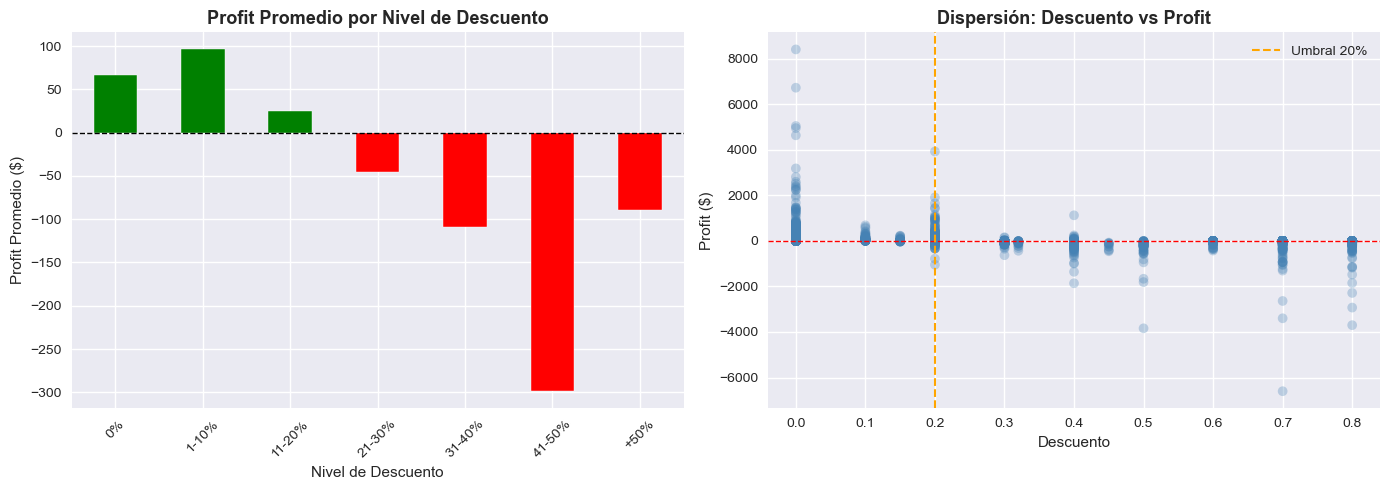

✅ Gráfico guardado como discount_vs_profit.png


In [28]:
# =============================================
# CELDA 9: Visualización - Profit por nivel de descuento
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Profit promedio por grupo de descuento
colores = ['green' if x > 0 else 'red' 
           for x in resumen_descuento.values]

resumen_descuento.plot(
    kind='bar', 
    ax=axes[0], 
    color=colores,
    edgecolor='white'
)
axes[0].set_title('Profit Promedio por Nivel de Descuento', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel de Descuento')
axes[0].set_ylabel('Profit Promedio ($)')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Dispersión Discount vs Profit
axes[1].scatter(
    df['Discount'], 
    df['Profit'], 
    alpha=0.3, 
    color='steelblue',
    edgecolors='none'
)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(x=0.2, color='orange', linestyle='--', linewidth=1.5, label='Umbral 20%')
axes[1].set_title('Dispersión: Descuento vs Profit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Descuento')
axes[1].set_ylabel('Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como discount_vs_profit.png")

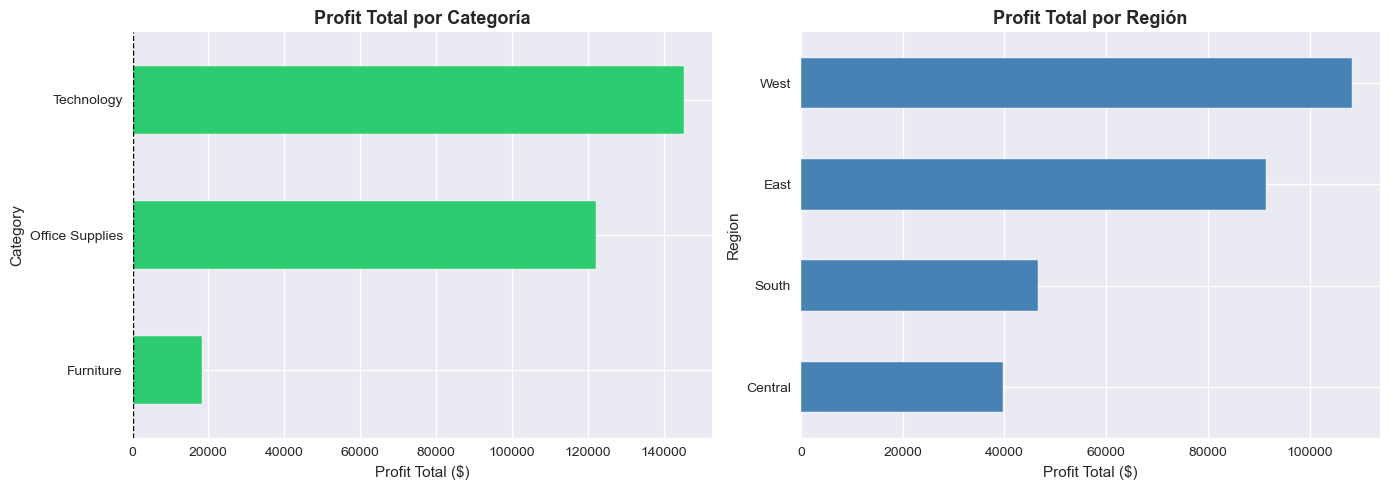

✅ Gráfico guardado como profit_categoria_region.png


In [25]:
# =============================================
# CELDA 10: Profit por Categoría y Región
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Profit total por Categoría
profit_categoria = df.groupby('Category')['Profit'].sum().sort_values()
colores_cat = ['green' if x < 0 else 'red' for x in profit_categoria]

profit_categoria.plot(
    kind='barh', 
    ax=axes[0], 
    color=colores_cat,
    edgecolor='white'
)
axes[0].set_title('Profit Total por Categoría', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Profit Total ($)')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)

# Gráfico 2: Profit total por Región
profit_region = df.groupby('Region')['Profit'].sum().sort_values()

profit_region.plot(
    kind='barh', 
    ax=axes[1], 
    color='steelblue',
    edgecolor='white'
)
axes[1].set_title('Profit Total por Región', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit Total ($)')

plt.tight_layout()
plt.savefig('profit_categoria_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como profit_categoria_region.png")

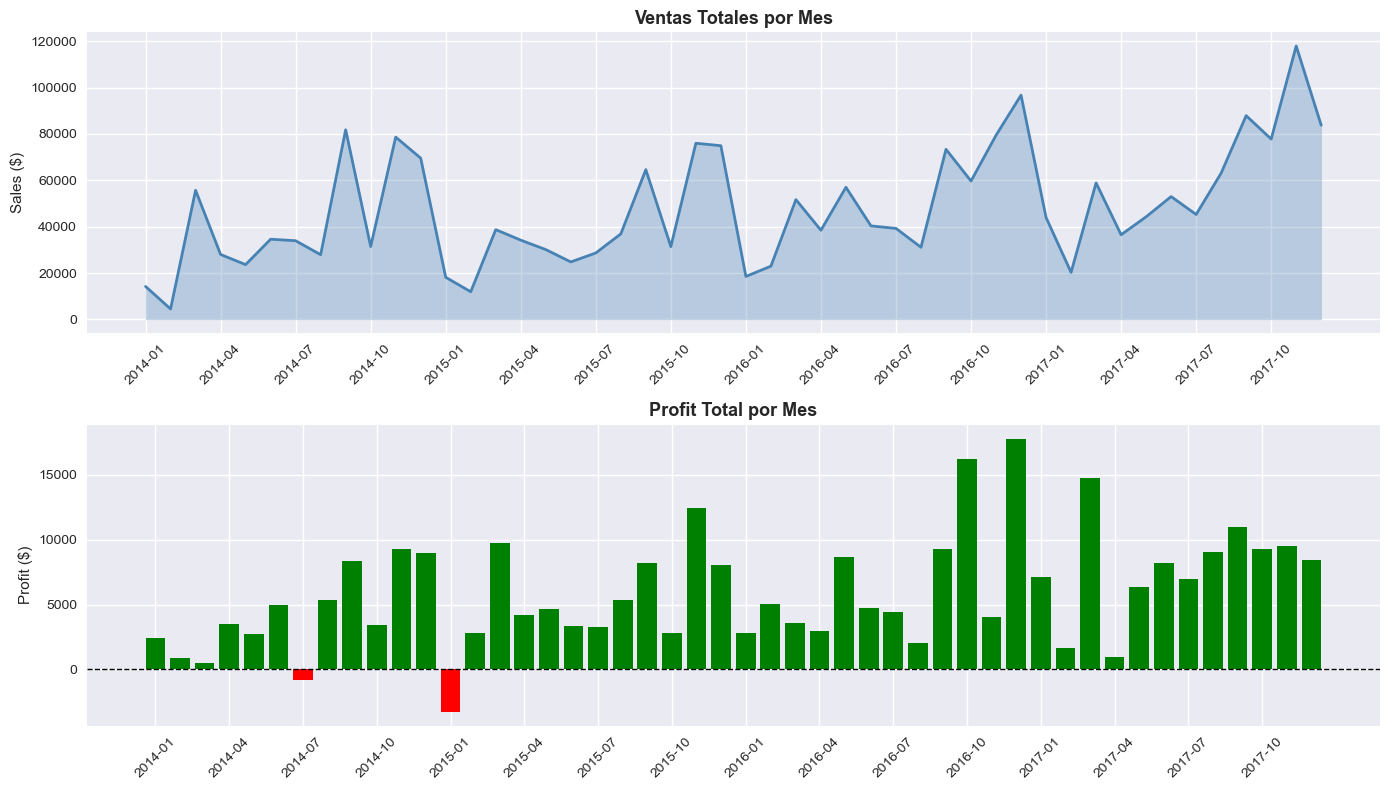

✅ Gráfico guardado


In [27]:
# =============================================
# CELDA 11: Análisis temporal de ventas y profit
# =============================================

# Convertir OrderDate a datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Agrupar por mes
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

tendencia = df.groupby('YearMonth').agg(
    Sales_Total  = ('Sales',  'sum'),
    Profit_Total = ('Profit', 'sum'),
    Transacciones = ('OrderID', 'count')
).reset_index()

tendencia['YearMonth'] = tendencia['YearMonth'].astype(str)

# Graficar
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Sales en el tiempo
axes[0].plot(tendencia['YearMonth'], tendencia['Sales_Total'], 
             color='steelblue', linewidth=2)
axes[0].fill_between(range(len(tendencia)), tendencia['Sales_Total'], 
                      alpha=0.3, color='steelblue')
axes[0].set_title('Ventas Totales por Mes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xticks(range(0, len(tendencia), 3))
axes[0].set_xticklabels(tendencia['YearMonth'][::3], rotation=45)

# Profit en el tiempo
colores_profit = ['green' if x > 0 else 'red' 
                  for x in tendencia['Profit_Total']]
axes[1].bar(range(len(tendencia)), tendencia['Profit_Total'], 
            color=colores_profit, edgecolor='none')
axes[1].set_title('Profit Total por Mes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xticks(range(0, len(tendencia), 3))
axes[1].set_xticklabels(tendencia['YearMonth'][::3], rotation=45)

plt.tight_layout()
plt.savefig('tendencia_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")